Importation des 2 dataframes

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Charger les données
ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv')

# On relie les 2 fichiers via la colonne commune "movieId"
df = ratings.merge(movies, on='movieId')

df.head()



,userId,movieId,rating,timestamp,title,genres
0,1,16,4.0,1217897793,Casino (1995),Crime|Drama
1,1,24,1.5,1217895807,Powder (1995),Drama|Sci-Fi
2,1,32,4.0,1217896246,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller
3,1,47,4.0,1217896556,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,4.0,1217896523,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


Nettoyage des donnees

In [2]:
df.isnull().sum()


userId       0
movieId      0
rating       0
timestamp    0
title        0
genres       0
dtype: int64

In [3]:
df.describe()

,userId,movieId,rating,timestamp
count,105339.000000,105339.000000,105339.000000,1.053390e+05
mean,364.924539,13381.312477,3.516850,1.130424e+09
std,197.486905,26170.456869,1.044872,1.802660e+08
min,1.000000,1.000000,0.500000,8.285650e+08
25%,192.000000,1073.000000,3.000000,9.711008e+08
50%,383.000000,2497.000000,3.500000,1.115154e+09
75%,557.000000,5991.000000,4.000000,1.275496e+09
max,668.000000,149532.000000,5.000000,1.452405e+09


Distribution des notes (graphique)

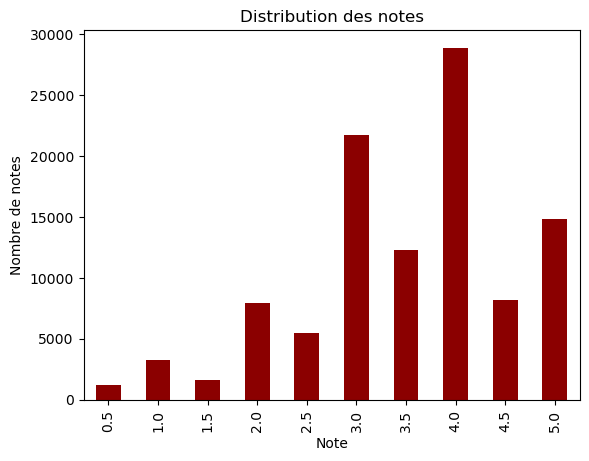

In [4]:
df['rating'].value_counts().sort_index().plot(kind='bar', color='darkred')
plt.title('Distribution des notes')
plt.xlabel('Note')
plt.ylabel('Nombre de notes')
plt.show()

Top 12 films les plus notés

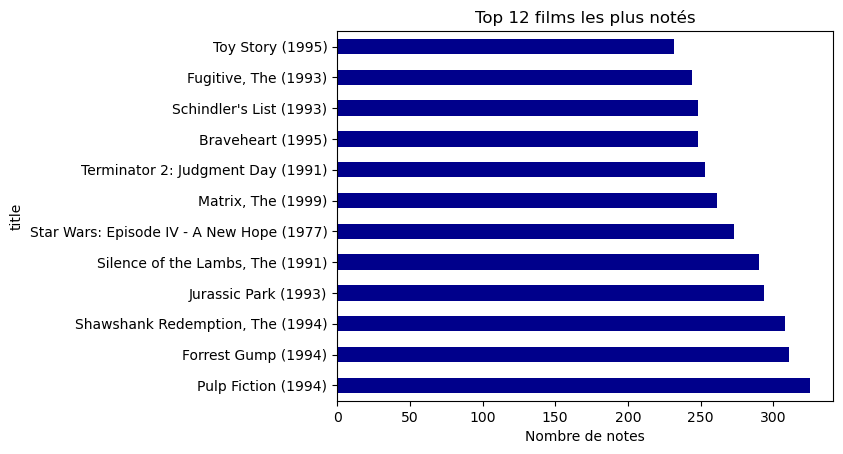

In [5]:
top_films = df.groupby('title')['rating'].count().sort_values(ascending=False).head(12)
top_films.plot(kind='barh', color='darkblue')
plt.title('Top 12 films les plus notés')
plt.xlabel('Nombre de notes')
plt.show()

Les Importations Necessaire.

In [6]:
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

Definition de X et Y

In [7]:
#values pour garder les valeurs numériques sans les titres de films
X = df[['userId', 'movieId']].values
y = df['rating'].values

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Train : {X_train.shape} | Test : {X_test.shape}")

Train : (84271, 2) | Test : (21068, 2)


In [9]:
knn = KNeighborsRegressor(n_neighbors=20)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

RMSE : 0.9652


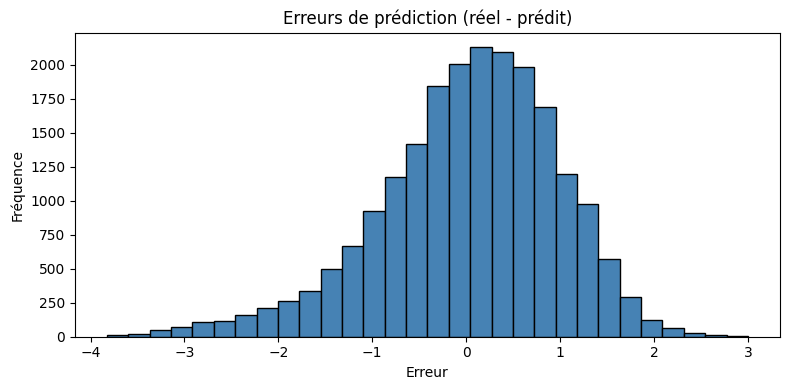

In [10]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE : {rmse:.4f}") # Différence entre les valeurs réelles et prédites en moyenne. + faible est mieux, puisque l'erreur est moins haute.

# Visualiser les prédictions vs réelles
plt.figure(figsize=(8, 4))
plt.hist(y_test - y_pred, bins=30, color='steelblue', edgecolor='black')
plt.title("Erreurs de prédiction (réel - prédit)")
plt.xlabel("Erreur")
plt.ylabel("Fréquence")
plt.tight_layout()
plt.show()

In [11]:
#Pour tester différents k
resultats = []

for k in [5, 10, 20, 30, 50]:
    knn_test = KNeighborsRegressor(n_neighbors=k)
    knn_test.fit(X_train, y_train)
    y_pred_test = knn_test.predict(X_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    resultats.append((k, rmse_test))
    print(f"k={k} | RMSE : {rmse_test:.4f}")

k=5 | RMSE : 1.0052
k=10 | RMSE : 0.9731
k=20 | RMSE : 0.9652
k=30 | RMSE : 0.9686
k=50 | RMSE : 0.9745


In [12]:
with open('model.pkl', 'wb') as f:
    pickle.dump(knn, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ model.pkl et scaler.pkl sauvegardés !")

✅ model.pkl et scaler.pkl sauvegardés !


Part 2 - Amélioration avec 2e Dataset TMDB

In [13]:
tmdb = pd.read_csv('tmdb_5000_movies.csv')
tmdb.head()

df['title_clean'] = df['title'].str.replace(r'\s*\(\d{4}\)', '', regex=True).str.strip()

print("MovieLens sample:")
print(df['title_clean'].head())
print("\nTMDB sample:")
print(tmdb['title'].head())

MovieLens sample:
0                                Casino
1                                Powder
2    Twelve Monkeys (a.k.a. 12 Monkeys)
3                  Seven (a.k.a. Se7en)
4                   Usual Suspects, The
Name: title_clean, dtype: str

TMDB sample:
0                                      Avatar
1    Pirates of the Caribbean: At World's End
2                                     Spectre
3                       The Dark Knight Rises
4                                 John Carter
Name: title, dtype: str


In [14]:
tmdb.info()

<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   str    
 2   homepage              1712 non-null   str    
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   str    
 5   original_language     4803 non-null   str    
 6   original_title        4803 non-null   str    
 7   overview              4800 non-null   str    
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   str    
 10  production_countries  4803 non-null   str    
 11  release_date          4802 non-null   str    
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   str    
 15  status                4803 non-n

In [15]:
# Merger via le titre nettoyé
df_ameliorer = df.merge(tmdb, left_on='title_clean', right_on='title', how='left')

# Nbre de films qui ont matché
matched = df_ameliorer['popularity'].notna().sum()
total = len(df_ameliorer)
print(f"Films matchés : {matched}/{total}")

# Remplir les valeurs manquantes avec la moyenne
df_ameliorer['popularity'] = df_ameliorer['popularity'].fillna(df_ameliorer['popularity'].mean())
df_ameliorer['vote_average'] = df_ameliorer['vote_average'].fillna(df_ameliorer['vote_average'].mean())
df_ameliorer['budget'] = df_ameliorer['budget'].fillna(0)

df_ameliorer.head()

Films matchés : 51182/105559


,userId,movieId,rating,timestamp,title_x,genres_x,title_clean,budget,genres_y,homepage,...,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title_y,vote_average,vote_count
0,1,16,4.0,1217897793,Casino (1995),Crime|Drama,Casino,52000000.0,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 80, ""name...",NaN,...,"[{""iso_3166_1"": ""FR"", ""name"": ""France""}, {""iso...",1995-11-22,116112375.0,178.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,No one stays at the top forever.,Casino,7.800000,1307.0
1,1,24,1.5,1217895807,Powder (1995),Drama|Sci-Fi,Powder,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.814454,NaN
2,1,32,4.0,1217896246,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller,Twelve Monkeys (a.k.a. 12 Monkeys),0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.814454,NaN
3,1,47,4.0,1217896556,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,Seven (a.k.a. Se7en),0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.814454,NaN
4,1,50,4.0,1217896523,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,"Usual Suspects, The",0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.814454,NaN


In [16]:
# Nouvelles features avec TMDB
X_ameliorer = df_ameliorer[['userId', 'movieId', 'popularity', 'vote_average', 'budget']].values
y_ameliorer = df_ameliorer['rating'].values

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_ameliorer, y_ameliorer, test_size=0.2, random_state=42
)

scaler_e = StandardScaler()
X_train_e = scaler_e.fit_transform(X_train_e)
X_test_e = scaler_e.transform(X_test_e)

knn_ameliorer = KNeighborsRegressor(n_neighbors=20)
knn_ameliorer.fit(X_train_e, y_train_e)

y_pred_e = knn_ameliorer.predict(X_test_e)
rmse_ameliorer = np.sqrt(mean_squared_error(y_test_e, y_pred_e))

print(f"RMSE sans TMDB : {rmse:.4f}")
print(f"RMSE avec TMDB : {rmse_ameliorer:.4f}")

RMSE sans TMDB : 0.9652
RMSE avec TMDB : 0.9675


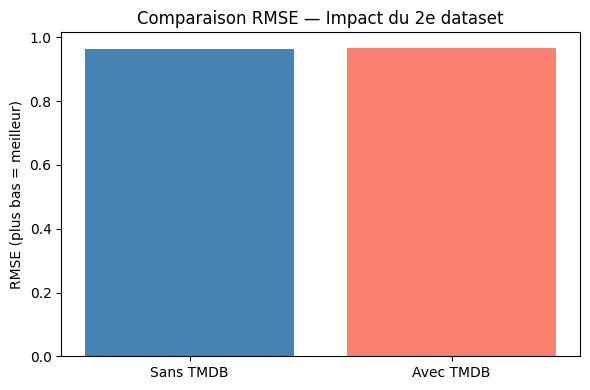

In [17]:
# Graphique comparatif
plt.figure(figsize=(6, 4))
plt.bar(['Sans TMDB', 'Avec TMDB'], 
        [rmse, rmse_ameliorer], 
        color=['steelblue', 'salmon'])
plt.title('Comparaison RMSE — Impact du 2e dataset')
plt.ylabel('RMSE (plus bas = meilleur)')
plt.tight_layout()
plt.show()

CONCLUSION : Même en tentant d'améliorer mon modèle à l'aide d'un second dataset, il n'y a aucun changement au RMSE, le niveau d'erreur est pratiquement identique.

In [ ]:
# PARTIE 3 — Modèle amélioré avec genres

# 1. Extraire les genres en colonnes (One-Hot Encoding)
genres_split = df['genres'].str.get_dummies('|')
print("Genres disponibles :")
print(genres_split.columns.tolist())
print(f"\n{len(genres_split.columns)} genres au total")

Genres disponibles :
['(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

20 genres au total


In [19]:
# 2. Combiner avec le dataset principal
df_genres = pd.concat([df[['userId', 'movieId', 'rating']], genres_split], axis=1)
print(df_genres.head())
print(df_genres.shape)

   userId  movieId  rating  (no genres listed)  Action  Adventure  Animation  \
0       1       16     4.0                   0       0          0          0   
1       1       24     1.5                   0       0          0          0   
2       1       32     4.0                   0       0          0          0   
3       1       47     4.0                   0       0          0          0   
4       1       50     4.0                   0       0          0          0   

   Children  Comedy  Crime  ...  Film-Noir  Horror  IMAX  Musical  Mystery  \
0         0       0      1  ...          0       0     0        0        0   
1         0       0      0  ...          0       0     0        0        0   
2         0       0      0  ...          0       0     0        0        1   
3         0       0      0  ...          0       0     0        0        1   
4         0       0      1  ...          0       0     0        0        1   

   Romance  Sci-Fi  Thriller  War  Western  
0    

In [20]:
# 3. Préparer X et y
feature_cols = ['userId', 'movieId'] + genres_split.columns.tolist()

X_genres = df_genres[feature_cols].values
y_genres = df_genres['rating'].values

X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X_genres, y_genres, test_size=0.2, random_state=42
)

scaler_g = StandardScaler()
X_train_g = scaler_g.fit_transform(X_train_g)
X_test_g = scaler_g.transform(X_test_g)

print(f"Nombre de features : {len(feature_cols)}")

Nombre de features : 22


In [21]:
# 4. Entraîner le nouveau modèle
knn_genres = KNeighborsRegressor(n_neighbors=20)
knn_genres.fit(X_train_g, y_train_g)

y_pred_g = knn_genres.predict(X_test_g)
rmse_genres = np.sqrt(mean_squared_error(y_test_g, y_pred_g))

print(f"RMSE sans genres : {rmse:.4f}")
print(f"RMSE avec genres : {rmse_genres:.4f}")

RMSE sans genres : 0.9652
RMSE avec genres : 0.9896


In [22]:
# 5. Sauvegarder le nouveau modèle
import pickle

with open('model.pkl', 'wb') as f:
    pickle.dump(knn_genres, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler_g, f)

# Sauvegarder aussi la liste des genres pour l'API
genre_columns = genres_split.columns.tolist()
with open('genres.pkl', 'wb') as f:
    pickle.dump(genre_columns, f)

print("✅ model.pkl, scaler.pkl et genres.pkl sauvegardés !")
print(f"Genres sauvegardés : {genre_columns}")

✅ model.pkl, scaler.pkl et genres.pkl sauvegardés !
Genres sauvegardés : ['(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


PROBLEME: FILM RECOMMENDÉ: Wizard of Oz(1939)(exemple) souvent recommendé parce que movie ID. KNN accorde bcp d'importance sur la proximité des id...

In [ ]:
#Construire la matrice utilisateur-film
matrice = df.pivot_table(
    index='userId', 
    columns='movieId', 
    values='rating'
).fillna(0)

print(f"Matrice : {matrice.shape[0]} utilisateurs x {matrice.shape[1]} films")

Matrice : 668 utilisateurs x 10325 films


In [56]:
#Entraîner KNN sur la matrice
from sklearn.neighbors import NearestNeighbors

knn_matrice = NearestNeighbors(n_neighbors=20, metric='cosine', algorithm='brute')
knn_matrice.fit(matrice.values)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",20
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'brute'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [58]:
#Fonction de recommandation
def recommander_par_matrice(userId, n=5):
    # Position de l'utilisateur dans la matrice
    user_index = matrice.index.get_loc(userId)
    
    # Trouver les 20 voisins les plus similaires
    distances, indices = knn_matrice.kneighbors(
        matrice.iloc[user_index].values.reshape(1, -1),
        n_neighbors=20
    )
    
    # Collecter les films aimés par les voisins (note >= 3.5)
    films_vus = set(matrice.columns[matrice.iloc[user_index] > 0])
    recommandations = {}
    
    for i in range(1, len(indices[0])):
        voisin_index = indices[0][i]
        similarite = 1 - distances[0][i]  # plus proche = plus similaire
        voisin_notes = matrice.iloc[voisin_index]
        
        for movie_id, note in voisin_notes.items():
            if movie_id not in films_vus and note >= 3.5:
                if movie_id not in recommandations:
                    recommandations[movie_id] = 0
                recommandations[movie_id] += note * similarite
    
    # Top N
    top = sorted(recommandations.items(), key=lambda x: x[1], reverse=True)[:n]
    
    print(f"\n🎬 Recommandations pour l'utilisateur {userId} :")
    for movie_id, score in top:
        titre = df[df['movieId'] == movie_id]['title'].values[0]
        print(f"  ✅ {titre} (score: {score:.2f})")

# Tester avec userId=1
recommander_par_matrice(452)


🎬 Recommandations pour l'utilisateur 452 :
  ✅ Fight Club (1999) (score: 4.35)
  ✅ American Beauty (1999) (score: 3.82)
  ✅ Sixth Sense, The (1999) (score: 3.75)
  ✅ Gladiator (2000) (score: 3.60)
  ✅ Saving Private Ryan (1998) (score: 3.33)


In [60]:
# CELLULE TEMPORAIRE — à supprimer après

userId_cible = 7

films_notes = df[df['userId'] == userId_cible][['title', 'rating']].sort_values('rating', ascending=False)

print(f"Films notés par userId={userId_cible} ({len(films_notes)} films) :\n")
for _, row in films_notes.iterrows():
    print(f"  {row['rating']} ⭐ → {row['title']}")

Films notés par userId=7 (161 films) :

  5.0 ⭐ → Twelve Monkeys (a.k.a. 12 Monkeys) (1995)
  5.0 ⭐ → Forrest Gump (1994)
  5.0 ⭐ → Seven (a.k.a. Se7en) (1995)
  5.0 ⭐ → Star Wars: Episode IV - A New Hope (1977)
  5.0 ⭐ → Die Hard: With a Vengeance (1995)
  5.0 ⭐ → Monty Python's Life of Brian (1979)
  5.0 ⭐ → Die Hard (1988)
  5.0 ⭐ → Silence of the Lambs, The (1991)
  5.0 ⭐ → Sin City (2005)
  5.0 ⭐ → Snatch (2000)
  5.0 ⭐ → Equilibrium (2002)
  5.0 ⭐ → Lucky Number Slevin (2006)
  5.0 ⭐ → Matrix, The (1999)
  5.0 ⭐ → South Park: Bigger, Longer and Uncut (1999)
  5.0 ⭐ → Fight Club (1999)
  5.0 ⭐ → Boondock Saints, The (2000)
  5.0 ⭐ → Austin Powers: The Spy Who Shagged Me (1999)
  5.0 ⭐ → Blade (1998)
  5.0 ⭐ → American History X (1998)
  5.0 ⭐ → Alien: Resurrection (1997)
  5.0 ⭐ → Saving Private Ryan (1998)
  5.0 ⭐ → Scream (1996)
  5.0 ⭐ → Starship Troopers (1997)
  5.0 ⭐ → Terminator, The (1984)
  5.0 ⭐ → Mars Attacks! (1996)
  5.0 ⭐ → Full Metal Jacket (1987)
  5.0 ⭐ → Alien (1

In [ ]:
#Sauvegarder en pickle
import pickle

with open('model.pkl', 'wb') as f:
    pickle.dump(knn_matrice, f)

with open('matrice.pkl', 'wb') as f:
    pickle.dump(matrice, f)

print("✅ model.pkl et matrice.pkl sauvegardés !")

✅ model.pkl et matrice.pkl sauvegardés !


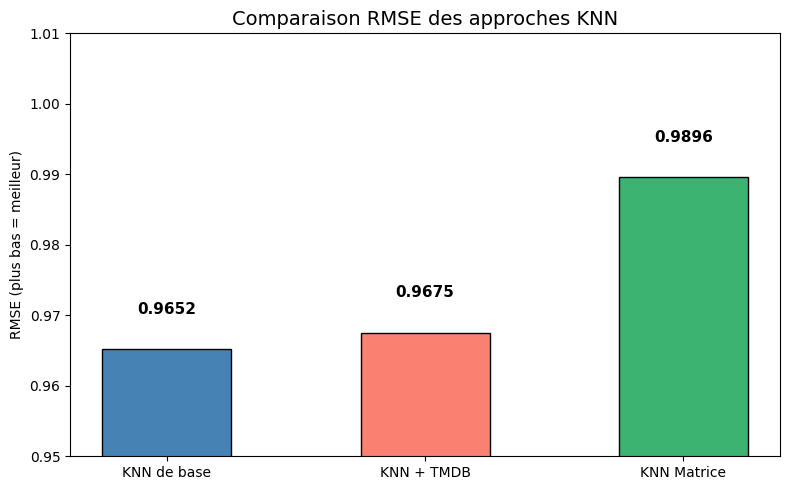

In [ ]:
# Comparaison RMSE des 3 approches
approches = ['KNN de base', 'KNN + TMDB', 'KNN Matrice']
rmses = [rmse, rmse_ameliorer, rmse_genres]  

couleurs = ['steelblue', 'salmon', 'mediumseagreen']

plt.figure(figsize=(8, 5))
barres = plt.bar(approches, rmses, color=couleurs, edgecolor='black', width=0.5)

# Ajouter les valeurs sur les barres
for barre, valeur in zip(barres, rmses):
    plt.text(
        barre.get_x() + barre.get_width() / 2,
        barre.get_height() + 0.005,
        f'{valeur:.4f}',
        ha='center', fontsize=11, fontweight='bold'
    )

plt.title('Comparaison RMSE des approches KNN', fontsize=14)
plt.ylabel('RMSE (plus bas = meilleur)')
plt.ylim(0.95, 1.01)
plt.tight_layout()
plt.show()

Intéressant de noter que le KNN Matrice a un pire RMSE, mais recommende des meilleurs films. A la fin, ce qui importe, c'est pas de prédire la note, mais plutot de recommender des bon films
et il semble que la Matrice trouve des meilleurs voisins

In [37]:
# CELLULE TEMPORAIRE — à supprimer après
user_index = matrice.index.get_loc(1)
distances_m, indices_m = knn_matrice.kneighbors(
    matrice.iloc[user_index].values.reshape(1, -1),
    n_neighbors=6
)

print("✅ Vrais voisins de userId=1 :\n")
for i in range(1, 6):
    voisin_index = indices_m[0][i]
    voisin_id = matrice.index[voisin_index]
    similarite = 1 - distances_m[0][i]
    
    films_aimes = matrice.iloc[voisin_index]
    films_aimes = films_aimes[films_aimes >= 4].sort_values(ascending=False).head(3)
    titres = [df[df['movieId'] == mid]['title'].values[0] 
              for mid in films_aimes.index]
    
    print(f"Voisin {i} (userId={voisin_id}) — similarité: {similarite:.3f}")
    print(f"  Films aimés: {titres}")
    print()

✅ Vrais voisins de userId=1 :

Voisin 1 (userId=348) — similarité: 0.414
  Films aimés: ['Pulp Fiction (1994)', 'Into the Wild (2007)', 'In Bruges (2008)']

Voisin 2 (userId=506) — similarité: 0.411
  Films aimés: ['Usual Suspects, The (1995)', 'Twelve Monkeys (a.k.a. 12 Monkeys) (1995)', 'Braveheart (1995)']

Voisin 3 (userId=493) — similarité: 0.406
  Films aimés: ['Dead Man Walking (1995)', 'Seven (a.k.a. Se7en) (1995)', 'Taxi Driver (1976)']

Voisin 4 (userId=158) — similarité: 0.404
  Films aimés: ['Léon: The Professional (a.k.a. The Professional) (Léon) (1994)', 'Seven (a.k.a. Se7en) (1995)', 'Usual Suspects, The (1995)']

Voisin 5 (userId=633) — similarité: 0.403
  Films aimés: ['Star Wars: Episode IV - A New Hope (1977)', 'Shawshank Redemption, The (1994)', 'Usual Suspects, The (1995)']



In [48]:
# Recréer le mauvais modèle
X_bad = df[['userId', 'movieId']].values
scaler_bad = StandardScaler()
X_bad_scaled = scaler_bad.fit_transform(X_bad)

knn_bad = NearestNeighbors(n_neighbors=6, metric='euclidean')
knn_bad.fit(X_bad_scaled)

# Simuler userId=1 regardant Star Wars (movieId=260)
point = scaler_bad.transform([[1, 260]])
distances, indices = knn_bad.kneighbors(point)

print("❌ Mauvais modèle — Voisins pour (userId=1, movieId=260 → Star Wars) :\n")
for i, idx in enumerate(indices[0]):
    voisin = df.iloc[idx]
    print(f"Voisin {i+1}:")
    print(f"  userId  : {voisin['userId']}")
    print(f"  Film    : {voisin['title']}")
    print(f"  Note    : {voisin['rating']}")
    print()

❌ Mauvais modèle — Voisins pour (userId=1, movieId=260 → Star Wars) :

Voisin 1:
  userId  : 1
  Film    : Star Wars: Episode IV - A New Hope (1977)
  Note    : 4.5

Voisin 2:
  userId  : 1
  Film    : Little Women (1994)
  Note    : 1.5

Voisin 3:
  userId  : 1
  Film    : Junior (1994)
  Note    : 0.5

Voisin 4:
  userId  : 1
  Film    : Miracle on 34th Street (1994)
  Note    : 0.5

Voisin 5:
  userId  : 1
  Film    : Pulp Fiction (1994)
  Note    : 4.0

Voisin 6:
  userId  : 1
  Film    : Clerks (1994)
  Note    : 4.0



In [36]:
# CELLULE TEMPORAIRE — à supprimer après

# Films déjà vus par userId=1
films_vus = set(df[df['userId'] == 1]['movieId'].tolist())

# Prédire pour des films non vus
tous_les_films = df['movieId'].unique()
films_non_vus = [f for f in tous_les_films if f not in films_vus]

# Prédire avec le mauvais modèle
from sklearn.neighbors import KNeighborsRegressor

knn_bad_reg = KNeighborsRegressor(n_neighbors=20)
knn_bad_reg.fit(X_bad_scaled, df['rating'].values)

predictions = []
for film_id in films_non_vus[:200]:
    point = scaler_bad.transform([[1, film_id]])
    note = knn_bad_reg.predict(point)[0]
    predictions.append((film_id, round(float(note), 2)))

top5 = sorted(predictions, key=lambda x: x[1], reverse=True)[:5]

print("❌ Recommandations du mauvais modèle pour userId=1 :\n")
for film_id, note in top5:
    titre = df[df['movieId'] == film_id]['title'].values[0]
    print(f"  {titre} → note prédite: {note}")

❌ Recommandations du mauvais modèle pour userId=1 :

  Old Yeller (1957) → note prédite: 4.45
  Harvey (1950) → note prédite: 4.33
  Grapes of Wrath, The (1940) → note prédite: 4.33
  Willy Wonka & the Chocolate Factory (1971) → note prédite: 4.3
  Old Man and the Sea, The (1958) → note prédite: 4.3
